In [6]:
import zipfile

import scipy
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['default', 'science', 'no-latex'])

from code_utils.utils_basic import PROJECT_PATH, PROJECTED_CRS

# 1. Preprocess bus stop passenger volume data

#### (1) Bus stop passenger volume data

In [7]:
zip_path = PROJECT_PATH / r'data/bus_network/bus_info_202210.zip'

with zipfile.ZipFile(zip_path, 'r') as zf:
    with zf.open(r'transport_node_bus_passenger_volume_202210.csv') as f:
         data = pd.read_csv(f, header=0, index_col=False)

# read data
data = (data
    .astype(dtype = {
            'TIME_PER_HOUR'        : np.int8,
            'PT_CODE'              : str,
            'TOTAL_TAP_IN_VOLUME'  : np.int32,
            'TOTAL_TAP_OUT_VOLUME' : np.int32
        }
    )
    # Rename columns
    .rename(columns = {
        'TIME_PER_HOUR'        : 'hour',
        'TOTAL_TAP_IN_VOLUME'  : 'in_vol',
        'TOTAL_TAP_OUT_VOLUME' : 'out_vol'
        }
    )
    # Map is_weekday values to boolean
    .assign(is_weekday =
        lambda x : x['DAY_TYPE'].map({'WEEKENDS/HOLIDAY': False, 'WEEKDAY': True})
    )
    # Standardize bus stop codes
    .assign(
        pt_code = lambda x : x['PT_CODE'].str.zfill(5)
    )
    # Select expected data
    # Bus stop, 2022-10, weekday, 6am-11pm
    .query(
        '(`PT_TYPE` == "BUS")'
        ' and (`YEAR_MONTH` == "2022-10")'
        ' and (`is_weekday` == True)'
        ' and (6 <= `hour` <= 23)'
    )
)

# Validate data types
print('\nData info:\n',
    data[['PT_TYPE', 'YEAR_MONTH', 'DAY_TYPE', 'is_weekday']].value_counts().to_dict(),
    '\nBus stop code:', data['pt_code'].str.len().value_counts().to_dict())



Data info:
 {('BUS', '2022-10', 'WEEKDAY', True): 89317} 
Bus stop code: {5: 89317}


#### (2) Extract tap-in and tap-out volume

In [8]:
# Tap-in volume only
data_in = (data[['hour', 'pt_code', 'in_vol']].copy()
    .pivot(columns="hour", index="pt_code", values='in_vol')
    .fillna(0.)
    .sort_index(axis=0)
    .sort_index(axis=1)
    # Passenger volume should be integer
    .astype(int)
)
# process column names, hour of the day
data_in.columns = data_in.columns.astype(str).str.zfill(2)

# Tap-out volume only
data_out = (data[['hour', 'pt_code', 'out_vol']].copy()
    .pivot(columns="hour", index="pt_code", values='out_vol')
    .fillna(0.)
    .sort_index(axis=0)
    .sort_index(axis=1)
    # Passenger volume should be integer
    .astype(int)
)
# process column names, hour of the day
data_out.columns = data_out.columns.astype(str).str.zfill(2)

# hour list
hour_li = data_out.columns.to_list()
hour_li.sort()

# Filter bus stops with total volume >= 100
# data = data[data.sum(axis=1) >= 100.]

# print data info
print('\nData info:',
    '\nData shape:', data_in.shape, data_out.shape,
    '\nNA values:', data_in.isna().sum().sum(), data_out.isna().sum().sum(),
)


Data info: 
Data shape: (5036, 18) (5036, 18) 
NA values: 0 0


#### (3) Remove low demand samples

In [9]:
# Filter bus stops with total volume >= 100
selected_stops = (
    set( data_in[data_in.sum(axis=1) >= 100].index.tolist() )
    .intersection(
        set( data_out[data_out.sum(axis=1) >= 100].index.tolist()) )
)

data_in  = data_in.reindex(selected_stops).copy()
data_out = data_out.reindex(selected_stops).copy()
print('Data shape:', data_in.shape, data_out.shape,)

Data shape: (4661, 18) (4661, 18)


#### (4) Bus stop locations

In [10]:
# Load bus stop locations
with zipfile.ZipFile(zip_path, 'r') as zf:
    with zf.open(r'bus_stop_20221020.csv') as f:
         busstop = pd.read_csv(f, header=0, index_col=False)

busstop = (busstop.
    astype(dtype = {'BusStopCode': str})
    .assign(pt_code = lambda x: x['BusStopCode'].str.zfill(5),)
)

# Convert to GeoDataFrame and project coordinates
busstop = (
    gpd.GeoDataFrame(
        busstop,
        geometry = gpd.points_from_xy(busstop['Longitude'], busstop['Latitude']),
        crs = 'EPSG:4326',)
    .to_crs(PROJECTED_CRS)
    .assign(
        proj_x = lambda x: x.geometry.x,
        proj_y = lambda x: x.geometry.y,)
)

<Axes: xlabel='proj_x', ylabel='proj_y'>

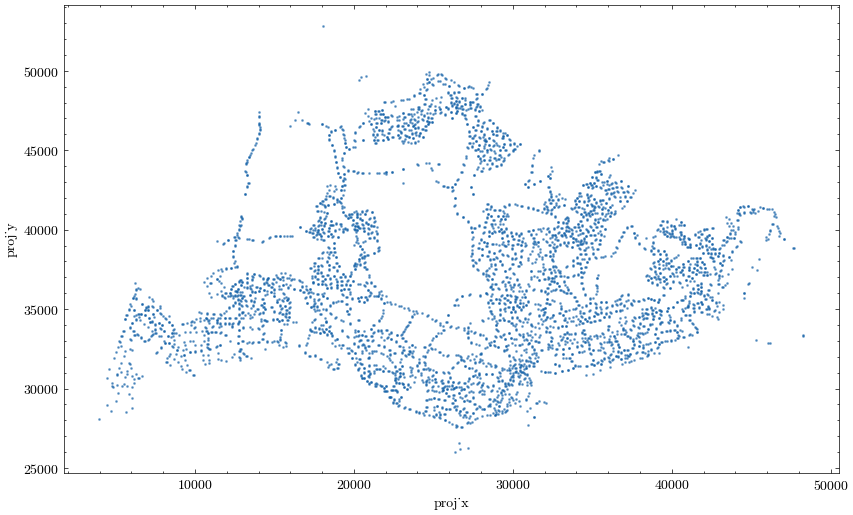

In [11]:
# Plot bus stop locations
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.set_aspect('equal')
busstop.plot.scatter(
    x = 'proj_x', y = 'proj_y',
    s = 1,
    figsize=(10, 10), alpha=0.5,
    ax = ax,
)

In [12]:
# join
data_in_loc = (data_in.copy().reset_index()
    .merge(busstop[['pt_code', 'proj_x', 'proj_y']].copy(),
        on = 'pt_code',
        how = 'inner',
        validate = 'one_to_one',)
    .fillna(0.)
    .sort_values(by='pt_code')
)

# Value to int
data_in_loc[hour_li] = data_in_loc[hour_li].round(0).astype(int)

In [ ]:
# save processed data
data_in_loc.to_csv('data/feature/busstop_volume_workday.csv',
    index=False, quoting=2,)

# busstop_li = list(
#     set( data_in[data_in.sum(axis=1) >= 100].index.tolist() )
#     .intersection(
#         set( data_out[data_out.sum(axis=1) >= 100].index.tolist() )
#     )
# )
# busstop_li.sort()
#
# print('\nBus stops with total volume >= 100:', len(busstop_li))